# DATA, INFERENCE AND APPLIED MACHINE LEARNING
## Assignment 3

**Name:** Charite Uwatwembi  
**Andrew ID:** cuwatwem  
**Date:** September 2026

This notebook contains my calculations, graphs, and short explanations. Each lettered part has its own code cell so that I can run and check each answer separately.

## Libraries used

- **pandas** for loading and organising data
- **NumPy** for numerical calculations
- **SciPy** for statistical tests
- **Matplotlib and Seaborn** for graphs
- **openpyxl** is used by pandas to read the Excel file

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = Path("data")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
print("Setup complete. Data folder:", DATA_DIR)

Setup complete. Data folder: data


# Question 1: Michelson speed-of-light measurements

## 1(a) Hypotheses and direction of the test

In [2]:
with open(DATA_DIR / "michelson_speed_of_light.json") as file:
    light_json = json.load(file)

light = pd.Series(
    [row["measured_speed_kmpersec"] for row in light_json["observations"]],
    name="speed_km_s"
)
accepted_speed = 299_734.5

print("H0: The population mean speed is 299,734.5 km/s.")
print("H1: The population mean speed is not 299,734.5 km/s.")
print("I use a two-tailed test because a bias could be above or below the accepted value.")

H0: The population mean speed is 299,734.5 km/s.
H1: The population mean speed is not 299,734.5 km/s.
I use a two-tailed test because a bias could be above or below the accepted value.


**Interpretation:** This setup tests for either a positive or a negative measurement bias. A two-tailed test is appropriate because the question does not predict the direction in advance.

## 1(b) Normality check

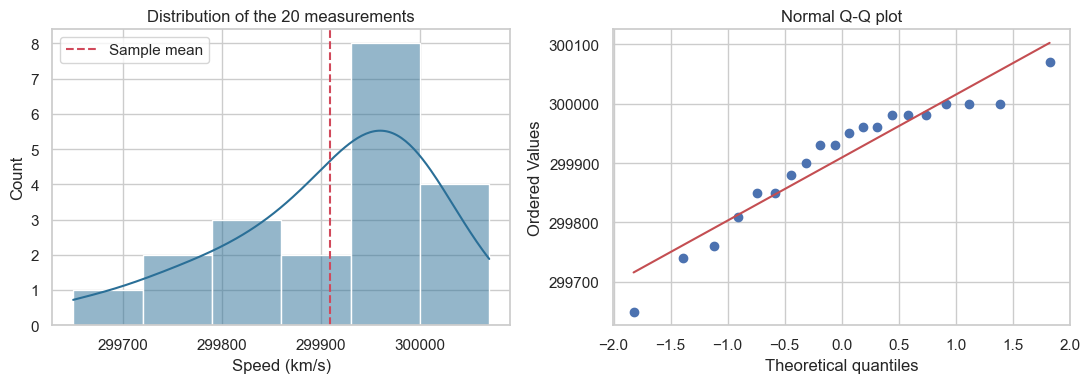

Sample size: 20
Shapiro-Wilk W = 0.920, p = 0.099
The sample is small, but the Q-Q plot is fairly straight and the Shapiro test does not reject normality.
This makes the one-sample t-test reasonable, although one unusual value would matter more in a small sample.


In [3]:
shapiro_w, shapiro_p = stats.shapiro(light)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(light, kde=True, color="#2A6F97", ax=axes[0])
axes[0].axvline(light.mean(), color="#D1495B", linestyle="--", label="Sample mean")
axes[0].set(title="Distribution of the 20 measurements", xlabel="Speed (km/s)")
axes[0].legend()

stats.probplot(light, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "q1_normality.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Sample size: {len(light)}")
print(f"Shapiro-Wilk W = {shapiro_w:.3f}, p = {shapiro_p:.3f}")
print("The sample is small, but the Q-Q plot is fairly straight and the Shapiro test does not reject normality.")
print("This makes the one-sample t-test reasonable, although one unusual value would matter more in a small sample.")

**Interpretation:** The plots do not show strong non-normality and Shapiro-Wilk gives p = 0.099. The t-test is reasonable, but with only 20 measurements one unusual value could still have a noticeable effect.

## 1(c) One-sample t-test

In [4]:
n_light = len(light)
mean_light = light.mean()
sd_light = light.std(ddof=1)
sem_light = sd_light / np.sqrt(n_light)
t_light, p_light = stats.ttest_1samp(light, accepted_speed)

q1_results = pd.DataFrame({
    "Result": [n_light, mean_light, sd_light, sem_light, t_light, n_light - 1, p_light]
}, index=["n", "Mean", "SD", "SEM", "t statistic", "df", "Two-tailed p-value"])
display(q1_results.round(6))

print(f"Test result: t({n_light - 1}) = {t_light:.3f}, p = {p_light:.3e}")
print("Conclusion: I reject H0. The measurements have a statistically significant positive bias.")

,Result
n,20.000000
Mean,299909.000000
SD,104.926039
SEM,23.462176
t statistic,7.437503
df,19.000000
Two-tailed p-value,0.000000


Test result: t(19) = 7.438, p = 4.864e-07
Conclusion: I reject H0. The measurements have a statistically significant positive bias.


**Interpretation:** The sample mean is above the accepted speed and the very small p-value leads me to reject H0. The evidence supports a positive measurement bias in Michelson's sample.

## 1(d) Size of the bias and effect of a larger sample

In [5]:
bias_km = mean_light - accepted_speed
bias_percent = bias_km / accepted_speed * 100

n_large = 200
sem_large = sd_light / np.sqrt(n_large)
t_large = bias_km / sem_large
p_large = 2 * stats.t.sf(abs(t_large), df=n_large - 1)

comparison = pd.DataFrame({
    "Sample size": [n_light, n_large],
    "Mean bias (km/s)": [bias_km, bias_km],
    "SEM (km/s)": [sem_light, sem_large],
    "t statistic": [t_light, t_large],
    "p-value": [p_light, p_large]
})
display(comparison.round(6))

print(f"Bias = {bias_km:.1f} km/s, or {bias_percent:.4f}% of the accepted speed.")
print(f"For n = 200: t(199) = {t_large:.3f}, p = {p_large:.3e}")
print("The bias is statistically clear, but it is small as a percentage of the accepted value.")
print("With n = 200 the bias stays the same, while the smaller SEM makes the p-value much smaller.")

,Sample size,Mean bias (km/s),SEM (km/s),t statistic,p-value
0,20,174.5,23.462176,7.437503,0.0
1,200,174.5,7.419391,23.519449,0.0


Bias = 174.5 km/s, or 0.0582% of the accepted speed.
For n = 200: t(199) = 23.519, p = 2.294e-59
The bias is statistically clear, but it is small as a percentage of the accepted value.
With n = 200 the bias stays the same, while the smaller SEM makes the p-value much smaller.


**Interpretation:** The bias is statistically clear but only 0.0582% of the accepted value. Raising n to 200 improves precision and confidence in the bias; it does not increase the size of the bias.

# Question 2: Chick weights: casein versus soybean feed

## 2(a) Hypotheses and test choice

In [6]:
chicks = pd.read_csv(DATA_DIR / "chickwts_casein_soybean.csv")
casein = chicks.loc[chicks["feed"] == "casein", "chick_weight_g"]
soybean = chicks.loc[chicks["feed"] == "soybean", "chick_weight_g"]

print("H0: Mean chick weight is the same for casein and soybean feed.")
print("H1: Mean chick weight is different for the two feeds.")
print("I use a two-tailed independent-samples Welch t-test.")
print("Welch's version is suitable because the group sizes and variances do not have to be equal.")

H0: Mean chick weight is the same for casein and soybean feed.
H1: Mean chick weight is different for the two feeds.
I use a two-tailed independent-samples Welch t-test.
Welch's version is suitable because the group sizes and variances do not have to be equal.


**Interpretation:** The chicks in the two feed groups are independent, so this is a two-sample rather than a paired test. I keep the test two-tailed because either feed could have produced the higher mean.

## 2(b) Descriptive statistics

In [7]:
q2_stats = chicks.groupby("feed")["chick_weight_g"].agg(
    n="count", mean="mean", sd="std", variance="var"
)
display(q2_stats.round(2))

print("The casein group has a higher average weight. Its spread is also slightly larger.")

,n,mean,sd,variance
feed,,,,
casein,12,323.58,64.43,4151.72
soybean,14,246.43,54.13,2929.96


The casein group has a higher average weight. Its spread is also slightly larger.


**Interpretation:** Casein has the higher sample mean, while its weights are also slightly more spread out. These summaries describe the sample before the formal test.

## 2(c) Welch t-test

In [8]:
n1, n2 = len(casein), len(soybean)
m1, m2 = casein.mean(), soybean.mean()
v1, v2 = casein.var(ddof=1), soybean.var(ddof=1)

mean_diff = m1 - m2
se_diff = np.sqrt(v1 / n1 + v2 / n2)
t_welch = mean_diff / se_diff
df_welch = (v1 / n1 + v2 / n2) ** 2 / (
    (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)
)
p_welch = 2 * stats.t.sf(abs(t_welch), df_welch)

welch_results = pd.DataFrame({
    "Mean difference (g)": [mean_diff],
    "SE difference": [se_diff],
    "t statistic": [t_welch],
    "df": [df_welch],
    "p-value": [p_welch]
})
display(welch_results.round(4))
print("The p-value is below 0.05, so I reject H0 and find a difference between the feeds.")

,Mean difference (g),SE difference,t statistic,df,p-value
0,77.1548,23.5639,3.2743,21.6345,0.0035


The p-value is below 0.05, so I reject H0 and find a difference between the feeds.


**Interpretation:** The Welch p-value is 0.0035, so I reject equal means at the 5% level. The observed difference is unlikely to be due to random sample variation alone.

## 2(d) Practical importance

In [9]:
critical_t = stats.t.ppf(0.975, df_welch)
ci_low = mean_diff - critical_t * se_diff
ci_high = mean_diff + critical_t * se_diff

pooled_sd = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
cohen_d = mean_diff / pooled_sd
hedges_g = cohen_d * (1 - 3 / (4 * (n1 + n2) - 9))

print(f"Mean difference: {mean_diff:.1f} g")
print(f"95% confidence interval: {ci_low:.1f} g to {ci_high:.1f} g")
print(f"Hedges' g: {hedges_g:.2f}")
print("This is a large observed difference, not only a small statistical effect.")
print("A feed decision would still need cost, nutrition, chick health, and evidence from a larger experiment.")

Mean difference: 77.2 g
95% confidence interval: 28.2 g to 126.1 g
Hedges' g: 1.26
This is a large observed difference, not only a small statistical effect.
A feed decision would still need cost, nutrition, chick health, and evidence from a larger experiment.


**Interpretation:** The confidence interval stays above zero and Hedges' g suggests a large observed effect. A feed choice would still need information about cost, health, mortality, and repeatability.

## 2(e) Boxplot

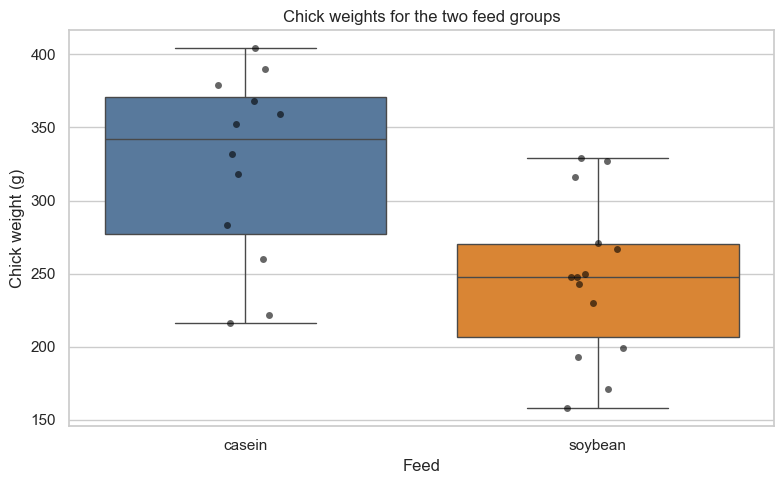

The casein distribution is shifted upward, although the groups still overlap.
The individual dots also show that there is variation within both feed groups.


In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=chicks, x="feed", y="chick_weight_g", hue="feed",
    order=["casein", "soybean"], hue_order=["casein", "soybean"],
    palette=["#4C78A8", "#F58518"], legend=False
)
sns.stripplot(
    data=chicks, x="feed", y="chick_weight_g",
    order=["casein", "soybean"], color="black", alpha=0.6, size=5
)
plt.title("Chick weights for the two feed groups")
plt.xlabel("Feed")
plt.ylabel("Chick weight (g)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

print("The casein distribution is shifted upward, although the groups still overlap.")
print("The individual dots also show that there is variation within both feed groups.")

**Interpretation:** The casein box and median are higher, with only limited overlap between the boxes. There is still variation within both groups, so the graph supports the test without saying that every casein-fed chick is heavier.

# Question 3: Fertility and GDP per capita in 2024

## 3(a) Scatter plot and scale choice

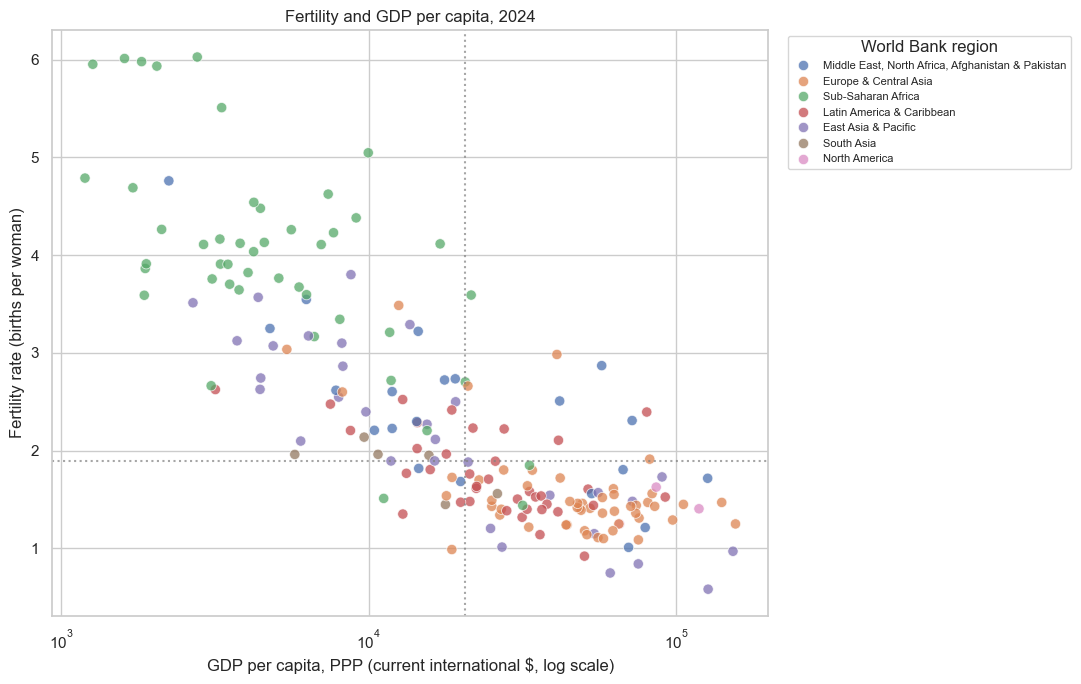

Complete country observations: 195
I used a log GDP axis because country income values cover a very wide range.
The log scale spreads out lower-income countries and makes the relationship easier to see.


In [11]:
world = pd.read_csv(DATA_DIR / "world_bank_2024_fertility_gdp.csv")
q3 = world.dropna(subset=["fertility_rate", "gdp_per_capita_ppp"]).copy()
q3 = q3[q3["gdp_per_capita_ppp"] > 0]

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=q3, x="gdp_per_capita_ppp", y="fertility_rate",
    hue="region", s=55, alpha=0.75
)
plt.xscale("log")
plt.axvline(q3["gdp_per_capita_ppp"].median(), color="grey", linestyle=":", alpha=0.7)
plt.axhline(q3["fertility_rate"].median(), color="grey", linestyle=":", alpha=0.7)
plt.title("Fertility and GDP per capita, 2024")
plt.xlabel("GDP per capita, PPP (current international $, log scale)")
plt.ylabel("Fertility rate (births per woman)")
plt.legend(title="World Bank region", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q3_fertility_gdp.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Complete country observations: {len(q3)}")
print("I used a log GDP axis because country income values cover a very wide range.")
print("The log scale spreads out lower-income countries and makes the relationship easier to see.")

**Interpretation:** The logarithmic GDP axis spreads countries across the graph instead of compressing most of them near zero. This makes the downward country-level pattern easier to read.

## 3(b) Pearson and Spearman correlations

In [12]:
log_gdp = np.log10(q3["gdp_per_capita_ppp"])

pearson_raw = stats.pearsonr(q3["gdp_per_capita_ppp"], q3["fertility_rate"])
pearson_log = stats.pearsonr(log_gdp, q3["fertility_rate"])
spearman_raw = stats.spearmanr(q3["gdp_per_capita_ppp"], q3["fertility_rate"])

q3_corr = pd.DataFrame({
    "Method": ["Pearson: raw GDP", "Pearson: log10 GDP", "Spearman: raw GDP"],
    "Correlation": [pearson_raw.statistic, pearson_log.statistic, spearman_raw.statistic],
    "p-value": [pearson_raw.pvalue, pearson_log.pvalue, spearman_raw.pvalue]
})
q3_corr["p-value"] = q3_corr["p-value"].map(lambda value: f"{value:.2e}")
display(q3_corr.round(4))

print("All three results show a strong negative relationship.")
print("The log-GDP Pearson value is stronger because the log scale makes the curved pattern more nearly linear.")

,Method,Correlation,p-value
0,Pearson: raw GDP,-0.6080,4.30e-21
1,Pearson: log10 GDP,-0.8261,5.89e-50
2,Spearman: raw GDP,-0.8148,1.39e-47


All three results show a strong negative relationship.
The log-GDP Pearson value is stronger because the log scale makes the curved pattern more nearly linear.


**Interpretation:** Log-Pearson and Spearman are both about −0.82, while raw-Pearson is weaker. This means the relationship is strongly decreasing but curved on the original GDP scale.

## 3(c) Extreme observations and sensitivity

In [13]:
q3["fertility_z"] = stats.zscore(q3["fertility_rate"])
q3["log_gdp"] = np.log10(q3["gdp_per_capita_ppp"])
q3["log_gdp_z"] = stats.zscore(q3["log_gdp"])
q3["extreme"] = (q3["fertility_z"].abs() > 2.5) | (q3["log_gdp_z"].abs() > 2.5)

extreme_countries = q3.loc[q3["extreme"], [
    "country", "fertility_rate", "gdp_per_capita_ppp", "fertility_z", "log_gdp_z"
]]
display(extreme_countries.round(3))

q3_no_extreme = q3.loc[~q3["extreme"]]
new_raw = stats.pearsonr(q3_no_extreme["gdp_per_capita_ppp"], q3_no_extreme["fertility_rate"]).statistic
new_log = stats.pearsonr(q3_no_extreme["log_gdp"], q3_no_extreme["fertility_rate"]).statistic
new_rank = stats.spearmanr(q3_no_extreme["gdp_per_capita_ppp"], q3_no_extreme["fertility_rate"]).statistic

sensitivity = pd.DataFrame({
    "Correlation": ["Pearson raw", "Pearson log GDP", "Spearman"],
    "All countries": [pearson_raw.statistic, pearson_log.statistic, spearman_raw.statistic],
    "Without |z| > 2.5": [new_raw, new_log, new_rank]
})
display(sensitivity.round(3))

print(f"Countries removed: {len(extreme_countries)}")
print("The correlations change only slightly, so the main conclusion is not driven by these extreme countries.")

,country,fertility_rate,gdp_per_capita_ppp,fertility_z,log_gdp_z
37,Central African Republic,5.954,1264.937,2.966,-2.289
38,Chad,6.028,2766.981,3.027,-1.616
44,"Congo, Dem. Rep.",5.981,1823.277,2.988,-1.975
122,Mali,5.510,3321.576,2.599,-1.459
143,Niger,5.935,2044.049,2.950,-1.876
176,"Somalia, Fed. Rep.",6.013,1604.291,3.015,-2.085


,Correlation,All countries,Without |z| > 2.5
0,Pearson raw,-0.608,-0.619
1,Pearson log GDP,-0.826,-0.810
2,Spearman,-0.815,-0.798


Countries removed: 6
The correlations change only slightly, so the main conclusion is not driven by these extreme countries.


**Interpretation:** Six high-fertility countries meet the |z| > 2.5 rule. Removing them changes the correlations only slightly, so the main conclusion is reasonably robust to these extreme points.

## 3(d) Limits of the cross-sectional result

In [14]:
limitations = [
    "This is association, not proof that higher GDP directly causes lower fertility.",
    "Education, health care, urbanisation, culture, and policy may affect both variables.",
    "One year cannot show how countries changed over time.",
    "Country averages hide differences within each country.",
    "A panel study would follow the same countries across many years and include time and country effects."
]

for point in limitations:
    print("-", point)

- This is association, not proof that higher GDP directly causes lower fertility.
- Education, health care, urbanisation, culture, and policy may affect both variables.
- One year cannot show how countries changed over time.
- Country averages hide differences within each country.
- A panel study would follow the same countries across many years and include time and country effects.


**Interpretation:** The 2024 comparison shows association, not a cause-and-effect result. Following the same countries over time would help separate within-country change from stable differences between countries.

# Question 4: UK monthly house prices

## 4(a) Full series and 12-month moving average

/Users/charite/CMU/DIAML/DIAML_AS3/Data-Inference-and-Applied-Machine-Learning/cuwatwem/.venv/lib/python3.9/site-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: Monthly!$A:$F.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


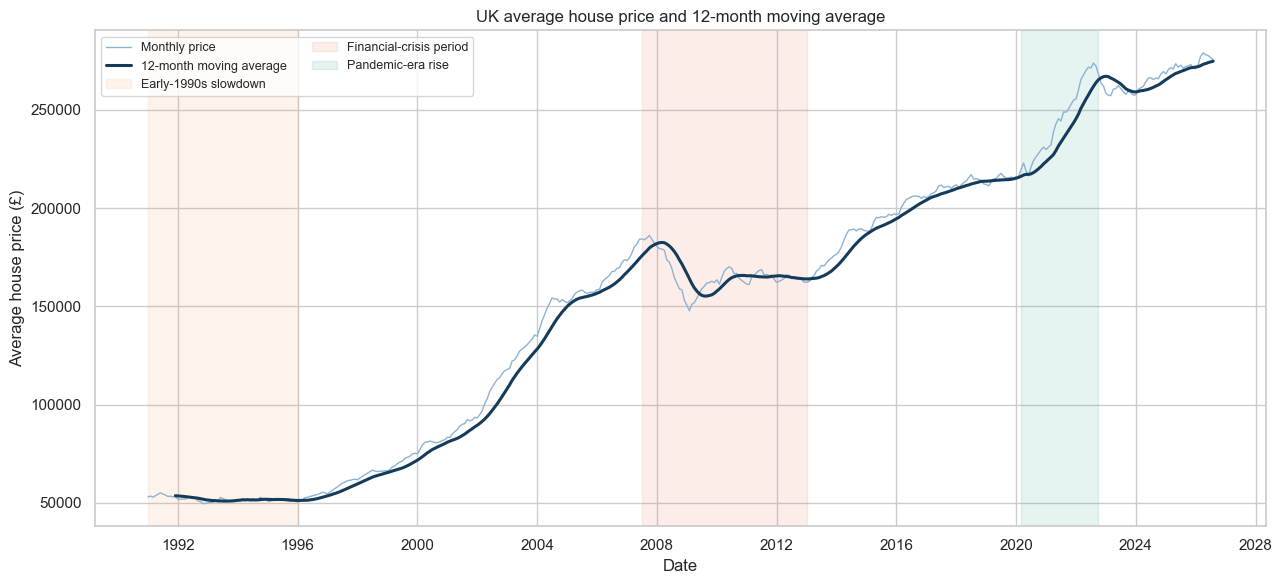

The moving average removes some monthly noise and makes the long phases clearer.
I marked the early-1990s slowdown, the financial-crisis period, and the pandemic-era rise.


In [15]:
house = pd.read_excel(DATA_DIR / "Monthly.xlsx", sheet_name="Monthly")
house = house.rename(columns={house.columns[0]: "date", "Average House Price": "house_price"})
house["date"] = pd.to_datetime(house["date"])
house = house[["date", "house_price"]].dropna().sort_values("date")
house["ma_12"] = house["house_price"].rolling(12).mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(house["date"], house["house_price"], color="#8DB3D3", linewidth=1, label="Monthly price")
ax.plot(house["date"], house["ma_12"], color="#153B5B", linewidth=2.2, label="12-month moving average")

phases = [
    ("1991-01-01", "1995-12-31", "Early-1990s slowdown", "#F4A261"),
    ("2007-07-01", "2012-12-31", "Financial-crisis period", "#E76F51"),
    ("2020-03-01", "2022-09-30", "Pandemic-era rise", "#2A9D8F")
]
for start, end, label, colour in phases:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=colour, alpha=0.12, label=label)

ax.set(title="UK average house price and 12-month moving average", xlabel="Date", ylabel="Average house price (£)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q4_house_prices.png", dpi=180, bbox_inches="tight")
plt.show()

print("The moving average removes some monthly noise and makes the long phases clearer.")
print("I marked the early-1990s slowdown, the financial-crisis period, and the pandemic-era rise.")

**Interpretation:** The moving average shows that UK house-price growth has not been constant. The early-1990s slowdown, financial-crisis period, and pandemic-era rise are three visibly different phases.

## 4(b) Year-on-year growth

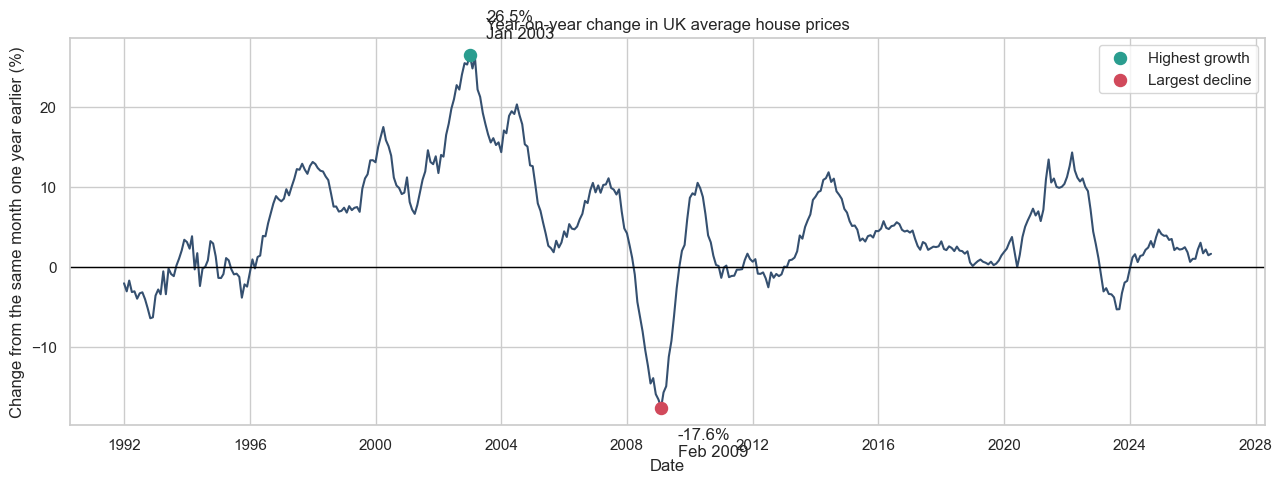

Highest YoY growth: 26.47% in January 2003
Largest YoY decline: -17.63% in February 2009
The steep 2009 fall lines up with the financial-crisis phase shown in part (a).


In [16]:
house["yoy_growth"] = house["house_price"].pct_change(12) * 100
max_yoy = house.loc[house["yoy_growth"].idxmax()]
min_yoy = house.loc[house["yoy_growth"].idxmin()]

plt.figure(figsize=(13, 5))
plt.plot(house["date"], house["yoy_growth"], color="#355070", linewidth=1.5)
plt.axhline(0, color="black", linewidth=1)
plt.scatter(max_yoy["date"], max_yoy["yoy_growth"], color="#2A9D8F", s=75, zorder=3, label="Highest growth")
plt.scatter(min_yoy["date"], min_yoy["yoy_growth"], color="#D1495B", s=75, zorder=3, label="Largest decline")
plt.annotate(f"{max_yoy['yoy_growth']:.1f}%\n{max_yoy['date']:%b %Y}", (max_yoy["date"], max_yoy["yoy_growth"]), xytext=(12, 12), textcoords="offset points")
plt.annotate(f"{min_yoy['yoy_growth']:.1f}%\n{min_yoy['date']:%b %Y}", (min_yoy["date"], min_yoy["yoy_growth"]), xytext=(12, -35), textcoords="offset points")
plt.title("Year-on-year change in UK average house prices")
plt.xlabel("Date")
plt.ylabel("Change from the same month one year earlier (%)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q4_yoy.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Highest YoY growth: {max_yoy['yoy_growth']:.2f}% in {max_yoy['date']:%B %Y}")
print(f"Largest YoY decline: {min_yoy['yoy_growth']:.2f}% in {min_yoy['date']:%B %Y}")
print("The steep 2009 fall lines up with the financial-crisis phase shown in part (a).")

**Interpretation:** The strongest rise was 26.47% in January 2003 and the strongest fall was −17.63% in February 2009. The fall matches the financial-crisis phase; the rise belongs to the earlier housing boom visible before it.

## 4(c) Monthly returns and autocorrelation

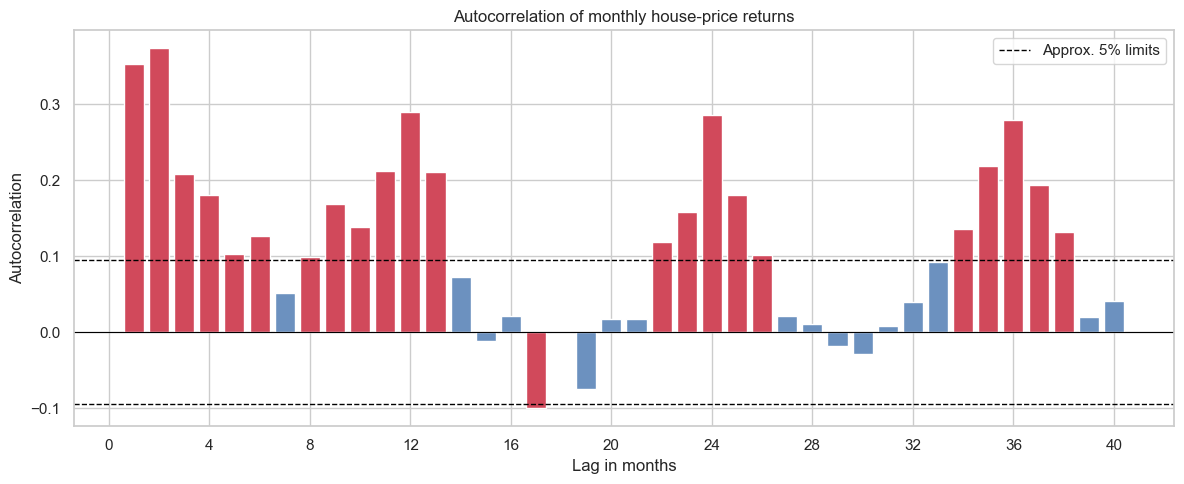

Approximate significance limits: ±0.095 = ±1.96/sqrt(427)
Significant lags: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 17, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38]
Positive values at 12, 24, and 36 months suggest persistence and an annual pattern.


In [17]:
house["monthly_return"] = house["house_price"].pct_change()
returns = house["monthly_return"].dropna()

lags = np.arange(1, 41)
acf_values = np.array([returns.autocorr(lag) for lag in lags])
limit = 1.96 / np.sqrt(len(returns))
colours = np.where(abs(acf_values) > limit, "#D1495B", "#6C91BF")

plt.figure(figsize=(12, 5))
plt.bar(lags, acf_values, color=colours)
plt.axhline(limit, color="black", linestyle="--", linewidth=1, label="Approx. 5% limits")
plt.axhline(-limit, color="black", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(np.arange(0, 41, 4))
plt.title("Autocorrelation of monthly house-price returns")
plt.xlabel("Lag in months")
plt.ylabel("Autocorrelation")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q4_acf.png", dpi=180, bbox_inches="tight")
plt.show()

significant_lags = lags[abs(acf_values) > limit]
print(f"Approximate significance limits: ±{limit:.3f} = ±1.96/sqrt({len(returns)})")
print("Significant lags:", significant_lags.tolist())
print("Positive values at 12, 24, and 36 months suggest persistence and an annual pattern.")

**Interpretation:** Several autocorrelations cross the approximate ±0.095 limits, including annual lags. Monthly house-price returns therefore show persistence and seasonality rather than behaving like independent noise.

## 4(d) Compound annual growth rates

In [18]:
def cagr(data):
    years = (data["date"].iloc[-1] - data["date"].iloc[0]).days / 365.25
    return (data["house_price"].iloc[-1] / data["house_price"].iloc[0]) ** (1 / years) - 1

full_period = house
pre_2008 = house[house["date"] < "2008-01-01"]
post_2008 = house[house["date"] >= "2008-01-01"]

q4_cagr = pd.DataFrame({
    "Period": ["Full sample", "Before 2008", "2008 onward"],
    "Start": [full_period["date"].min(), pre_2008["date"].min(), post_2008["date"].min()],
    "End": [full_period["date"].max(), pre_2008["date"].max(), post_2008["date"].max()],
    "CAGR (%)": [cagr(full_period) * 100, cagr(pre_2008) * 100, cagr(post_2008) * 100]
})
display(q4_cagr.round(2))

print("House-price growth was much faster before 2008 than after 2008.")
print("This shows why the chosen time period can change the investment story.")

,Period,Start,End,CAGR (%)
0,Full sample,1991-01-01,2026-08-01,4.74
1,Before 2008,1991-01-01,2007-12-01,7.56
2,2008 onward,2008-01-01,2026-08-01,2.30


House-price growth was much faster before 2008 than after 2008.
This shows why the chosen time period can change the investment story.


**Interpretation:** The full CAGR of 4.74% hides a large difference between 7.56% before 2008 and 2.30% afterward. The split gives a clearer picture of how the market changed around the financial crisis.

# Question 5: UK house prices versus the FTSE 100

## 5(a) Normalised comparison

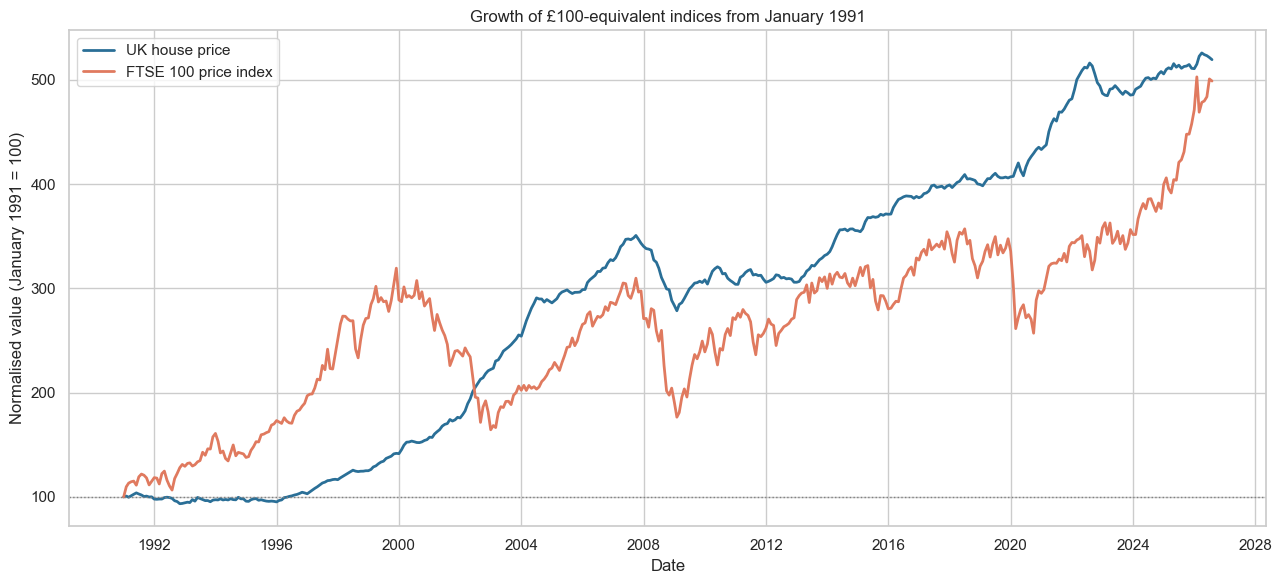

Common monthly observations: 428
House-price index at the end: 519.2
FTSE price index at the end: 498.7


In [19]:
ftse = pd.read_csv(DATA_DIR / "FTSE100.csv")
ftse["Date"] = pd.to_datetime(ftse["Date"])
ftse = ftse[["Date", "Adj Close"]].rename(columns={"Date": "date", "Adj Close": "ftse"})

comparison = house.merge(ftse, on="date", how="inner")
comparison = comparison[(comparison["date"] >= "1991-01-01") & (comparison["date"] <= "2026-08-31")].copy()
comparison["House price index"] = comparison["house_price"] / comparison["house_price"].iloc[0] * 100
comparison["FTSE 100 index"] = comparison["ftse"] / comparison["ftse"].iloc[0] * 100

plt.figure(figsize=(13, 6))
plt.plot(comparison["date"], comparison["House price index"], color="#2A6F97", linewidth=2, label="UK house price")
plt.plot(comparison["date"], comparison["FTSE 100 index"], color="#E07A5F", linewidth=2, label="FTSE 100 price index")
plt.axhline(100, color="grey", linestyle=":", linewidth=1)
plt.title("Growth of £100-equivalent indices from January 1991")
plt.xlabel("Date")
plt.ylabel("Normalised value (January 1991 = 100)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q5_normalized.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Common monthly observations: {len(comparison)}")
print(f"House-price index at the end: {comparison['House price index'].iloc[-1]:.1f}")
print(f"FTSE price index at the end: {comparison['FTSE 100 index'].iloc[-1]:.1f}")

**Interpretation:** A starting value of 100 makes proportional growth directly comparable. Housing ends slightly higher, although this graph compares price indices and not complete investment returns.

## 5(b) Annualised FTSE return

In [20]:
comparison["ftse_return"] = comparison["ftse"].pct_change()
years = (comparison["date"].iloc[-1] - comparison["date"].iloc[0]).days / 365.25
ftse_cagr = (comparison["ftse"].iloc[-1] / comparison["ftse"].iloc[0]) ** (1 / years) - 1

year_end = comparison.set_index("date")["ftse"].resample("YE").last()
calendar_returns = year_end.pct_change().dropna()
arithmetic_mean = calendar_returns.mean()

print(f"FTSE geometric annual return (CAGR): {ftse_cagr * 100:.2f}%")
print(f"Arithmetic mean of calendar-year returns: {arithmetic_mean * 100:.2f}%")
print("I use CAGR for long-run growth because it respects compounding from the first value to the last.")
print("The arithmetic mean treats each year's return separately and can overstate compounded growth.")

FTSE geometric annual return (CAGR): 4.62%
Arithmetic mean of calendar-year returns: 5.25%
I use CAGR for long-run growth because it respects compounding from the first value to the last.
The arithmetic mean treats each year's return separately and can overstate compounded growth.


**Interpretation:** CAGR is the better long-run measure because it includes compounding from the first value to the last. The arithmetic mean answers a different question and is higher here.

## 5(c) Return and risk comparison

In [21]:
comparison["house_return"] = comparison["house_price"].pct_change()

house_cagr = (comparison["house_price"].iloc[-1] / comparison["house_price"].iloc[0]) ** (1 / years) - 1
house_vol = comparison["house_return"].std() * np.sqrt(12)
ftse_vol = comparison["ftse_return"].std() * np.sqrt(12)

q5_summary = pd.DataFrame({
    "Asset": ["UK average house price", "FTSE 100 price index"],
    "CAGR (%)": [house_cagr * 100, ftse_cagr * 100],
    "Annualised monthly volatility (%)": [house_vol * 100, ftse_vol * 100]
})
display(q5_summary.round(2))

print("In this price-only comparison, the two long-run returns are close.")
print("The FTSE has much higher month-to-month volatility than the published national house-price series.")

,Asset,CAGR (%),Annualised monthly volatility (%)
0,UK average house price,4.74,3.67
1,FTSE 100 price index,4.62,13.38


In this price-only comparison, the two long-run returns are close.
The FTSE has much higher month-to-month volatility than the published national house-price series.


**Interpretation:** The two CAGRs are close, but FTSE volatility is much higher. The housing estimate is smoother partly because it is a national monthly index rather than the price of one property.

## 5(d) Investment conclusion and missing information

In [22]:
print("My conclusion:")
print("The house-price series finishes slightly higher and looks smoother, but this is not a complete investment comparison.")
print("I would not choose an asset using this graph alone.")
print()
print("Information still needed for a fair comparison:")
missing_items = [
    "FTSE dividends and reinvestment",
    "rental income from housing",
    "maintenance, insurance, taxes, and transaction costs",
    "mortgage interest and leverage",
    "inflation-adjusted returns",
    "liquidity and time needed to sell",
    "diversification and differences between individual properties"
]
for item in missing_items:
    print("-", item)

My conclusion:
The house-price series finishes slightly higher and looks smoother, but this is not a complete investment comparison.
I would not choose an asset using this graph alone.

Information still needed for a fair comparison:
- FTSE dividends and reinvestment
- rental income from housing
- maintenance, insurance, taxes, and transaction costs
- mortgage interest and leverage
- inflation-adjusted returns
- liquidity and time needed to sell
- diversification and differences between individual properties


**Interpretation:** Housing looks slightly better only under this limited price-only comparison. Dividends, rent, financing, costs, taxes, inflation, liquidity, and diversification are needed before making a fair investment choice.

# Overall conclusion

This assignment showed me that the method must fit the data and the question. A small p-value needs an effect size and practical context, a strong correlation does not prove causation, and a long-run average can hide major changes between periods.

The clearest example is the investment comparison: housing looks slightly stronger and smoother on price alone, but the result is incomplete without dividends, rent, costs, tax, leverage, inflation, and liquidity. My main takeaway is to explain the assumptions and limits next to every numerical result.